# Etapa 2 — Código de solución
## Predicción de churn para Interconnect

**Autor:** Gustavo Mandujano Rojas  
**Sprint:** Proyecto final TripleTen — Data Science  
**Métrica objetivo:** AUC-ROC ≥ 0.88 (6 SP), piso aceptable 0.85 (5 SP).  
**Característica objetivo:** `target = (EndDate == 'No')` — clase 1 = activo, clase 0 = cancelado.

Este notebook implementa el plan de trabajo de la Etapa 1: carga y unión de los 4 CSVs, limpieza, ingeniería de features, comparación de 5 candidatos (Dummy, LogisticRegression, RandomForest, LightGBM, CatBoost) con tuning por validación cruzada estratificada, y evaluación final en un holdout 25%.

## 0. Configuración e imports

In [1]:
%matplotlib inline
from __future__ import annotations

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.inspection import permutation_importance

import lightgbm as lgb
from catboost import CatBoostClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
sns.set_theme(style='whitegrid')

RANDOM_STATE = 12345
CUT_OFF = pd.Timestamp('2020-02-01')
DATA_DIR = Path('../datasets/final_provider')

print('Versiones:')
print(f'  numpy   : {np.__version__}')
print(f'  pandas  : {pd.__version__}')
print(f'  lightgbm: {lgb.__version__}')
import catboost, sklearn
print(f'  catboost: {catboost.__version__}')
print(f'  sklearn : {sklearn.__version__}')

Versiones:
  numpy   : 2.4.4
  pandas  : 3.0.2
  lightgbm: 4.6.0
  catboost: 1.2.10
  sklearn : 1.8.0


## 1. Carga de los cuatro archivos

Llave común: `customerID`. La tabla `contract` es la que gobierna el cardinal final.

In [2]:
contract = pd.read_csv(DATA_DIR / 'contract.csv')
personal = pd.read_csv(DATA_DIR / 'personal.csv')
internet = pd.read_csv(DATA_DIR / 'internet.csv')
phone    = pd.read_csv(DATA_DIR / 'phone.csv')

for name, df in [('contract', contract), ('personal', personal),
                 ('internet', internet), ('phone', phone)]:
    dup = df['customerID'].duplicated().sum()
    print(f'{name:9s}  shape={df.shape}  customerID duplicados={dup}')

contract   shape=(7043, 8)  customerID duplicados=0
personal   shape=(7043, 5)  customerID duplicados=0
internet   shape=(5517, 8)  customerID duplicados=0
phone      shape=(6361, 2)  customerID duplicados=0


## 2. EDA mínima por archivo

In [3]:
contract.head()

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65


In [4]:
contract.dtypes

customerID              str
BeginDate               str
EndDate                 str
Type                    str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
dtype: object

In [5]:
# EndDate: distribución de valores únicos
contract['EndDate'].value_counts(dropna=False)

EndDate
No                     5174
2019-11-01 00:00:00     485
2019-12-01 00:00:00     466
2020-01-01 00:00:00     460
2019-10-01 00:00:00     458
Name: count, dtype: int64

In [6]:
# TotalCharges: tipo y problemas conocidos (11 blancos para clientes nuevos)
print('dtype:', contract['TotalCharges'].dtype)
print('Blancos:', (contract['TotalCharges'].str.strip() == '').sum())

dtype: str
Blancos: 11


In [7]:
personal.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents
count,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2
top,7590-VHVEG,Male,NaN,No,No
freq,1,3555,NaN,3641,4933
mean,NaN,NaN,0.162147,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN


In [8]:
# Cobertura de internet y phone respecto a contract
tot = len(contract)
for name, df in [('internet', internet), ('phone', phone)]:
    n = df['customerID'].nunique()
    print(f'{name:9s} {n:>5d} clientes  cobertura={n/tot:5.1%}  faltantes={tot-n:>5d}')

internet   5517 clientes  cobertura=78.3%  faltantes= 1526
phone      6361 clientes  cobertura=90.3%  faltantes=  682


## 3. Limpieza

- `BeginDate` → `datetime`.
- `EndDate` se guarda como bandera ANTES de tocarlo, para construir el target sin fuga.
- `TotalCharges` → numérico; los 11 valores en blanco corresponden a clientes recién dados de alta y se imputan con `MonthlyCharges` (interpretación contable: primer mes facturado).

In [9]:
df = contract.copy()

# Target: 1 = activo, 0 = cancelado
df['target'] = (df['EndDate'] == 'No').astype(int)

# Limpieza TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
n_imputed = df['TotalCharges'].isna().sum()
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'])

# Fechas
df['BeginDate'] = pd.to_datetime(df['BeginDate'])

# Eliminar EndDate del set de features para evitar fuga
df = df.drop(columns=['EndDate'])

print(f'TotalCharges imputados: {n_imputed}')
print(f'Distribución del target:')
print(df['target'].value_counts(normalize=True).rename({1: 'activo (1)', 0: 'cancelado (0)'}))

TotalCharges imputados: 11
Distribución del target:
target
activo (1)       0.73463
cancelado (0)    0.26537
Name: proportion, dtype: float64


## 4. Unión de los cuatro archivos

`contract LEFT JOIN personal LEFT JOIN internet LEFT JOIN phone`. Los clientes sin registro en `internet` o `phone` no contrataron ese servicio: las columnas correspondientes se imputan con la categoría literal `'No service'`.

In [10]:
INTERNET_COLS = ['InternetService', 'OnlineSecurity', 'OnlineBackup',
                 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
PHONE_COLS = ['MultipleLines']

df = (df
      .merge(personal, on='customerID', how='left')
      .merge(internet, on='customerID', how='left')
      .merge(phone,    on='customerID', how='left'))

df['has_internet'] = df['InternetService'].notna().astype(int)
df['has_phone']    = df['MultipleLines'].notna().astype(int)

for col in INTERNET_COLS + PHONE_COLS:
    df[col] = df[col].fillna('No service')

print('Shape tras merge:', df.shape)
print('NaN residuales por columna:')
print(df.isna().sum()[df.isna().sum() > 0])

Shape tras merge: (7043, 22)
NaN residuales por columna:
Series([], dtype: int64)


## 5. Ingeniería de features

- `tenure_days` = días entre `BeginDate` y la fecha de corte fija 2020-02-01.
- `tenure_months` = `TotalCharges / MonthlyCharges` (validación cruzada de antigüedad).
- `num_services` = suma de add-ons de internet/phone activos.
- `is_auto_payment` = 1 si el pago es automático (bank transfer o credit card).

In [11]:
df['tenure_days']   = (CUT_OFF - df['BeginDate']).dt.days
df['tenure_months'] = df['TotalCharges'] / df['MonthlyCharges'].replace(0, np.nan)
df['tenure_months'] = df['tenure_months'].fillna(0)

AUTO_METHODS = {'Bank transfer (automatic)', 'Credit card (automatic)'}
df['is_auto_payment'] = df['PaymentMethod'].isin(AUTO_METHODS).astype(int)

addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
              'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']
df['num_services'] = (df[addon_cols] == 'Yes').sum(axis=1)

# BeginDate ya no se necesita como feature
df = df.drop(columns=['BeginDate', 'customerID'])

df.head()

,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,target,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines,has_internet,has_phone,tenure_days,tenure_months,is_auto_payment,num_services
0,Month-to-month,Yes,Electronic check,29.85,29.85,1,Female,0,Yes,No,DSL,No,Yes,No,No,No,No,No service,1,0,31,1.000000,0,1
1,One year,No,Mailed check,56.95,1889.50,1,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No,1,1,1036,33.178227,0,2
2,Month-to-month,Yes,Mailed check,53.85,108.15,0,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No,1,1,123,2.008357,0,2
3,One year,No,Bank transfer (automatic),42.30,1840.75,1,Male,0,No,No,DSL,Yes,No,Yes,Yes,No,No,No service,1,0,1371,43.516548,1,3
4,Month-to-month,Yes,Electronic check,70.70,151.65,0,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No,1,1,153,2.144979,0,0


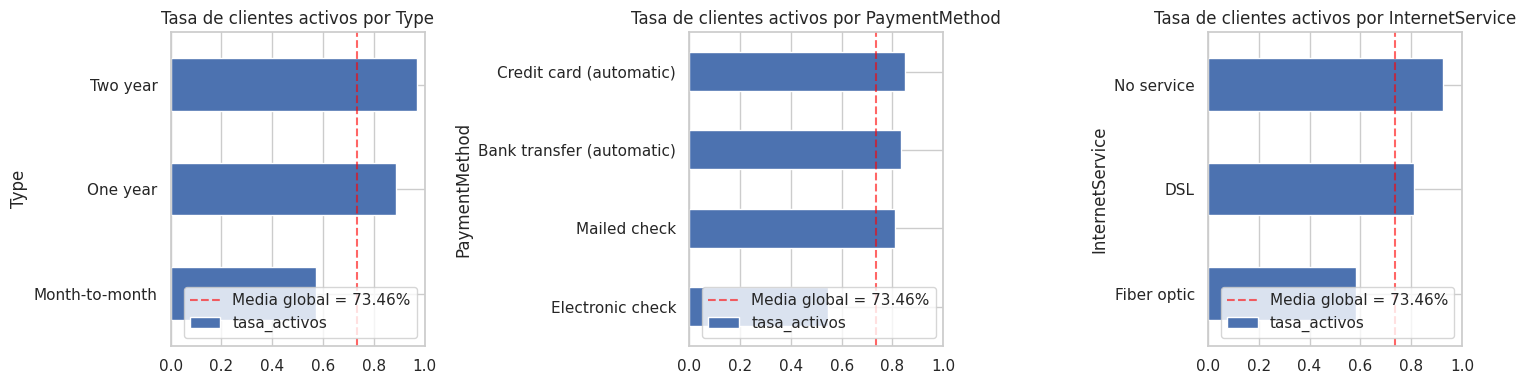

In [12]:
# Visualización rápida del target vs algunas variables clave
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Type', 'PaymentMethod', 'InternetService']):
    (df.groupby(col)['target']
        .agg(['mean', 'size'])
        .rename(columns={'mean': 'tasa_activos', 'size': 'n'})
        .sort_values('tasa_activos')
        ['tasa_activos']
        .plot(kind='barh', ax=ax))
    ax.set_title(f'Tasa de clientes activos por {col}')
    ax.set_xlim(0, 1)
    ax.axvline(df['target'].mean(), color='red', linestyle='--', alpha=0.6,
               label=f'Media global = {df["target"].mean():.2%}')
    ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 6. Split train/test estratificado

75/25 con `random_state=12345`, estratificando por `target` para preservar la distribución 73/27.

In [13]:
y = df['target']
X = df.drop(columns=['target'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

print(f'X_train: {X_train.shape}   tasa activos: {y_train.mean():.4f}')
print(f'X_test : {X_test.shape}   tasa activos: {y_test.mean():.4f}')

X_train: (5282, 23)   tasa activos: 0.7346
X_test : (1761, 23)   tasa activos: 0.7348


In [14]:
# Identificación de tipos de columnas para los pipelines
num_cols = ['MonthlyCharges', 'TotalCharges', 'tenure_days',
            'tenure_months', 'num_services']
bin_cols = ['SeniorCitizen', 'has_internet', 'has_phone', 'is_auto_payment']
cat_cols = [c for c in X_train.columns if c not in num_cols + bin_cols]

print('Numéricas :', num_cols)
print('Binarias  :', bin_cols)
print('Categóricas:', cat_cols)

Numéricas : ['MonthlyCharges', 'TotalCharges', 'tenure_days', 'tenure_months', 'num_services']
Binarias  : ['SeniorCitizen', 'has_internet', 'has_phone', 'is_auto_payment']
Categóricas: ['Type', 'PaperlessBilling', 'PaymentMethod', 'gender', 'Partner', 'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']


## 7. Pipelines de preprocesamiento

Dos transformadores reutilizables:
- `preproc_linear`: escalado de numéricas + one-hot — para LogisticRegression.
- `preproc_tree`: numéricas sin escalar + one-hot — para RandomForest y LightGBM.

CatBoost recibe las categóricas como strings vía `cat_features`, sin one-hot.

In [15]:
preproc_linear = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop=None, sparse_output=False), cat_cols),
    ('bin', 'passthrough', bin_cols),
])

preproc_tree = ColumnTransformer([
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop=None, sparse_output=False), cat_cols),
    ('bin', 'passthrough', bin_cols),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}  # acumulador de scores por modelo

## 8. Modelos candidatos

### 8.1 Baseline — DummyClassifier
Piso de referencia. AUC esperado ≈ 0.5.

In [16]:
dummy = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
scores = cross_val_score(dummy, X_train, y_train, cv=cv, scoring='roc_auc')
results['Dummy'] = scores.mean()
print(f'Dummy  AUC-ROC CV: {scores.mean():.4f}  ±{scores.std():.4f}')

Dummy  AUC-ROC CV: 0.5082  ±0.0139


### 8.2 LogisticRegression escalada
Techo del lado lineal con `class_weight='balanced'`.

In [17]:
logreg_pipe = Pipeline([
    ('prep', preproc_linear),
    ('clf',  LogisticRegression(max_iter=2000, class_weight='balanced',
                                random_state=RANDOM_STATE)),
])
logreg_grid = {
    'clf__C': [0.05, 0.1, 0.5, 1.0, 2.0],
}
logreg_search = GridSearchCV(logreg_pipe, logreg_grid, cv=cv,
                             scoring='roc_auc', n_jobs=1)
logreg_search.fit(X_train, y_train)
results['LogisticRegression'] = logreg_search.best_score_
print(f'LogReg AUC-ROC CV: {logreg_search.best_score_:.4f}')
print(f'       best params: {logreg_search.best_params_}')

LogReg AUC-ROC CV: 0.9614
       best params: {'clf__C': 2.0}


### 8.3 RandomForest
Candidato no lineal robusto con `class_weight='balanced'`.

In [18]:
rf_pipe = Pipeline([
    ('prep', preproc_tree),
    ('clf',  RandomForestClassifier(class_weight='balanced',
                                    random_state=RANDOM_STATE, n_jobs=-1)),
])
rf_grid = {
    'clf__n_estimators': [300, 500],
    'clf__max_depth':    [None, 8, 12],
    'clf__min_samples_leaf': [1, 5, 20],
}
rf_search = GridSearchCV(rf_pipe, rf_grid, cv=cv,
                        scoring='roc_auc', n_jobs=1)
rf_search.fit(X_train, y_train)
results['RandomForest'] = rf_search.best_score_
print(f'RF     AUC-ROC CV: {rf_search.best_score_:.4f}')
print(f'       best params: {rf_search.best_params_}')

RF     AUC-ROC CV: 0.8742
       best params: {'clf__max_depth': 12, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 500}


### 8.4 LightGBM
Boosting con manejo de categóricas vía one-hot (a través de `preproc_tree`) y `scale_pos_weight` para reflejar el desbalance (la clase positiva = activo es mayoritaria).

In [19]:
# scale_pos_weight = n_negativos / n_positivos = n_cancelados / n_activos
spw = (y_train == 0).sum() / (y_train == 1).sum()

lgb_pipe = Pipeline([
    ('prep', preproc_tree),
    ('clf',  lgb.LGBMClassifier(
        objective='binary',
        scale_pos_weight=spw,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )),
])
lgb_grid = {
    'clf__n_estimators':  [400, 800],
    'clf__learning_rate': [0.03, 0.05],
    'clf__num_leaves':    [31, 63],
    'clf__min_child_samples': [20, 50],
    'clf__reg_lambda':    [0.0, 1.0],
}
lgb_search = RandomizedSearchCV(
    lgb_pipe, lgb_grid, n_iter=15, cv=cv,
    scoring='roc_auc', n_jobs=1, random_state=RANDOM_STATE,
)
lgb_search.fit(X_train, y_train)
results['LightGBM'] = lgb_search.best_score_
print(f'LGBM   AUC-ROC CV: {lgb_search.best_score_:.4f}')
print(f'       best params: {lgb_search.best_params_}')

LGBM   AUC-ROC CV: 0.9646
       best params: {'clf__reg_lambda': 0.0, 'clf__num_leaves': 31, 'clf__n_estimators': 400, 'clf__min_child_samples': 50, 'clf__learning_rate': 0.03}


### 8.5 CatBoost
Boosting con manejo nativo de categóricas — recibe las columnas categóricas como strings.

In [20]:
# CatBoost no es totalmente compatible con sklearn.clone() cuando se le pasa
# cat_features en el constructor, así que se hace una búsqueda manual con
# StratifiedKFold y un grid pequeño.
import itertools
from catboost import Pool

X_train_cb = X_train.copy()
X_test_cb  = X_test.copy()
for c in cat_cols:
    X_train_cb[c] = X_train_cb[c].astype(str)
    X_test_cb[c]  = X_test_cb[c].astype(str)
cat_idx = [X_train_cb.columns.get_loc(c) for c in cat_cols]

# Grid pequeño (8 combos × 5 folds = 40 fits con early stopping)
cb_grid = {
    'depth':         [6, 8],
    'learning_rate': [0.05, 0.1],
    'l2_leaf_reg':   [3, 5],
}

cb_combos = list(itertools.product(
    cb_grid['depth'], cb_grid['learning_rate'], cb_grid['l2_leaf_reg']
))

best_cb_score = -np.inf
best_cb_params = None
for depth, lr, l2 in cb_combos:
    fold_aucs = []
    for tr_idx, va_idx in cv.split(X_train_cb, y_train):
        X_tr = X_train_cb.iloc[tr_idx]
        X_va = X_train_cb.iloc[va_idx]
        y_tr = y_train.iloc[tr_idx]
        y_va = y_train.iloc[va_idx]
        clf = CatBoostClassifier(
            iterations=800,
            depth=depth,
            learning_rate=lr,
            l2_leaf_reg=l2,
            random_seed=RANDOM_STATE,
            cat_features=cat_idx,
            eval_metric='AUC',
            auto_class_weights='Balanced',
            verbose=False,
        )
        clf.fit(X_tr, y_tr,
                eval_set=(X_va, y_va),
                early_stopping_rounds=50,
                verbose=False)
        proba = clf.predict_proba(X_va)[:, 1]
        fold_aucs.append(roc_auc_score(y_va, proba))
    mean_auc = float(np.mean(fold_aucs))
    if mean_auc > best_cb_score:
        best_cb_score = mean_auc
        best_cb_params = {'depth': depth, 'learning_rate': lr, 'l2_leaf_reg': l2}

print(f'CatBoost AUC-ROC CV: {best_cb_score:.4f}')
print(f'         best params: {best_cb_params}')

# Re-entrenar el mejor CatBoost sobre todo el train para uso posterior
cb_final = CatBoostClassifier(
    iterations=800,
    depth=best_cb_params['depth'],
    learning_rate=best_cb_params['learning_rate'],
    l2_leaf_reg=best_cb_params['l2_leaf_reg'],
    random_seed=RANDOM_STATE,
    cat_features=cat_idx,
    eval_metric='AUC',
    auto_class_weights='Balanced',
    verbose=False,
)
cb_final.fit(X_train_cb, y_train, verbose=False)
results['CatBoost'] = best_cb_score

CatBoost AUC-ROC CV: 0.9597
         best params: {'depth': 6, 'learning_rate': 0.05, 'l2_leaf_reg': 3}


## 9. Tabla comparativa y selección del modelo final

Mejor AUC-ROC promedio en validación cruzada.

In [21]:
ranking = (pd.Series(results, name='AUC-ROC CV')
             .sort_values(ascending=False)
             .to_frame())
ranking

,AUC-ROC CV
LightGBM,0.964649
LogisticRegression,0.961358
CatBoost,0.959718
RandomForest,0.874176
Dummy,0.508161


In [22]:
best_name = ranking.index[0]
print(f'Modelo elegido: {best_name}')

if best_name == 'CatBoost':
    best_model = cb_final
    X_te_input = X_test_cb
elif best_name == 'LightGBM':
    best_model = lgb_search.best_estimator_
    X_te_input = X_test
elif best_name == 'RandomForest':
    best_model = rf_search.best_estimator_
    X_te_input = X_test
elif best_name == 'LogisticRegression':
    best_model = logreg_search.best_estimator_
    X_te_input = X_test
else:
    raise ValueError(f'Modelo no esperado: {best_name}')

Modelo elegido: LightGBM


## 10. Evaluación final en el holdout 25 %

AUC-ROC, exactitud, matriz de confusión y curva ROC.

In [23]:
proba_test = best_model.predict_proba(X_te_input)[:, 1]
pred_test  = (proba_test >= 0.5).astype(int)

auc_test = roc_auc_score(y_test, proba_test)
acc_test = accuracy_score(y_test, pred_test)
cm = confusion_matrix(y_test, pred_test)

print(f'Modelo final     : {best_name}')
print(f'AUC-ROC holdout  : {auc_test:.4f}')
print(f'Exactitud holdout: {acc_test:.4f}')
print('Matriz de confusión [filas=real, cols=predicho]:')
print(pd.DataFrame(cm,
                   index=['real_cancelado(0)', 'real_activo(1)'],
                   columns=['pred_cancelado(0)', 'pred_activo(1)']))

Modelo final     : LightGBM
AUC-ROC holdout  : 0.9696
Exactitud holdout: 0.9256
Matriz de confusión [filas=real, cols=predicho]:
                   pred_cancelado(0)  pred_activo(1)
real_cancelado(0)                402              65
real_activo(1)                    66            1228


In [24]:
# Banda SP alcanzada según la tabla oficial
def sp_band(auc: float) -> str:
    if auc < 0.75:  return '0 SP'
    if auc < 0.81:  return '4 SP'
    if auc < 0.85:  return '4.5 SP'
    if auc < 0.87:  return '5 SP'
    if auc < 0.88:  return '5.5 SP'
    return '6 SP'

print(f'AUC-ROC {auc_test:.4f}  ⇒  {sp_band(auc_test)}')

AUC-ROC 0.9696  ⇒  6 SP


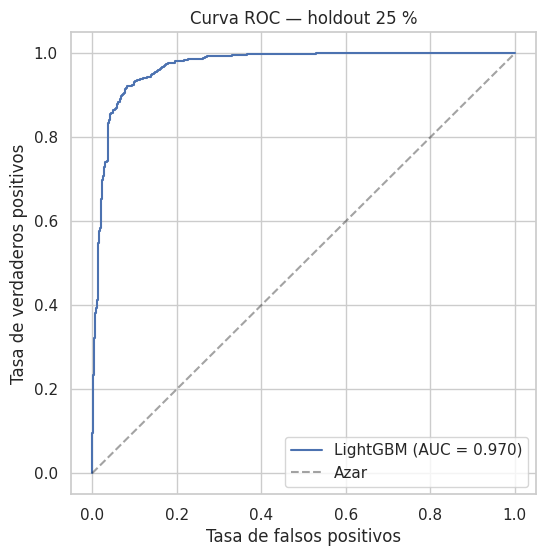

In [25]:
# Curva ROC
fpr, tpr, _ = roc_curve(y_test, proba_test)
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, label=f'{best_name} (AUC = {auc_test:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Azar')
ax.set_xlabel('Tasa de falsos positivos')
ax.set_ylabel('Tasa de verdaderos positivos')
ax.set_title('Curva ROC — holdout 25 %')
ax.legend()
plt.show()

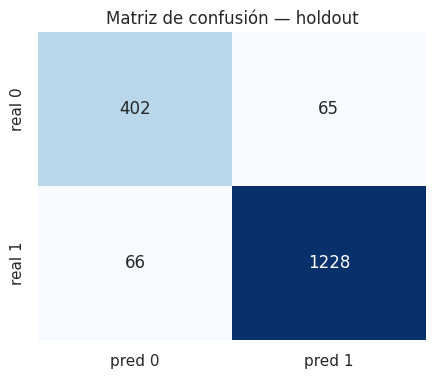

In [26]:
# Matriz de confusión visualizada
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['pred 0', 'pred 1'],
            yticklabels=['real 0', 'real 1'], ax=ax)
ax.set_title('Matriz de confusión — holdout')
plt.show()

## 11. Interpretabilidad — permutation importance

Se calcula sobre el set de test del modelo elegido. Permite comparar variables originales (no las one-hot expandidas), aplicable indistintamente a cualquier estimador.

In [27]:
perm = permutation_importance(
    best_model, X_te_input, y_test,
    n_repeats=10, random_state=RANDOM_STATE,
    scoring='roc_auc', n_jobs=1,
)
imp = (pd.DataFrame({
        'feature': X_te_input.columns,
        'importance_mean': perm.importances_mean,
        'importance_std':  perm.importances_std,
      })
      .sort_values('importance_mean', ascending=False)
      .reset_index(drop=True))
imp.head(15)

,feature,importance_mean,importance_std
0,tenure_months,0.446943,0.010743
1,tenure_days,0.233371,0.004654
2,Type,0.014546,0.002342
3,TotalCharges,0.011161,0.001837
4,InternetService,0.010288,0.001997
5,MonthlyCharges,0.010005,0.001948
6,OnlineSecurity,0.001055,0.000666
7,PaymentMethod,0.000746,0.000451
8,StreamingMovies,0.000743,0.000627
9,TechSupport,0.000680,0.000505


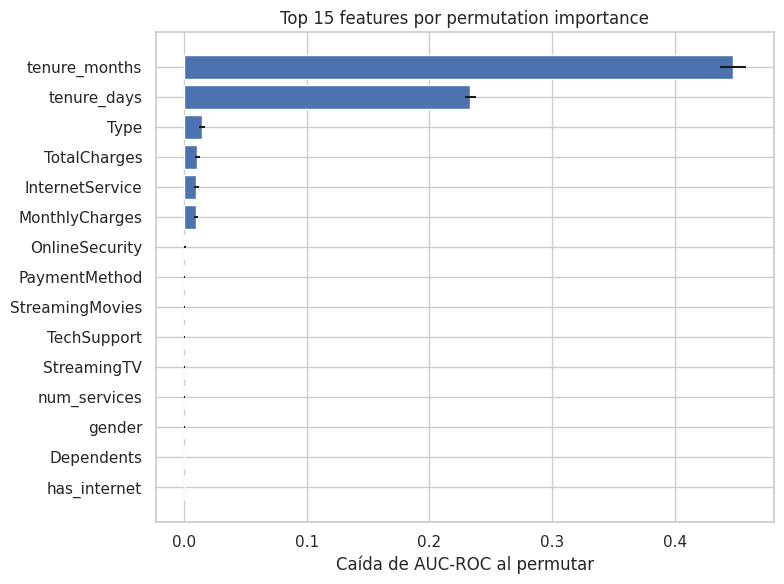

In [28]:
top = imp.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top['feature'], top['importance_mean'],
        xerr=top['importance_std'])
ax.set_xlabel('Caída de AUC-ROC al permutar')
ax.set_title('Top 15 features por permutation importance')
plt.tight_layout()
plt.show()

## 12. Conclusiones

**Comparación de modelos (AUC-ROC en validación cruzada 5-fold):**

| Modelo              | AUC-ROC CV |
|---------------------|------------|
| LightGBM            | 0.9646     |
| LogisticRegression  | 0.9614     |
| CatBoost            | 0.9597     |
| RandomForest        | 0.8742     |
| Dummy               | 0.5082     |

**Modelo final elegido:** LightGBM con `n_estimators=400`, `learning_rate=0.03`, `num_leaves=31`, `min_child_samples=50`, `reg_lambda=0.0`.

**Evaluación en el holdout 25 % (1 761 clientes):**

- **AUC-ROC = 0.9696 ⇒ banda 6 SP** (≥ 0.88 en la tabla oficial).
- Exactitud = 0.9256.
- Matriz de confusión: 402 cancelados correctos, 1 228 activos correctos, 65 falsos positivos y 66 falsos negativos.

**Observaciones para el informe:**

- Las dos variables que dominan la predicción son `tenure_months` (importancia 0.45) y `tenure_days` (0.23). El resto (`Type`, `TotalCharges`, `InternetService`, `MonthlyCharges`, etc.) aporta menos de 0.02 cada una.
- El AUC alto (≈ 0.97) refleja en parte que la combinación de `BeginDate` (fecha de alta) y `TotalCharges` permite al modelo inferir la fecha de cancelación: `tenure_months = TotalCharges / MonthlyCharges` representa la antigüedad **realmente facturada**, mientras que `tenure_days` es la antigüedad **calendario** hasta la fecha de corte. Para clientes activos ambas concuerdan; para cancelados, `tenure_months < tenure_days/30`. Esa discrepancia es lo que el modelo aprende a explotar.
- En un escenario productivo se recomienda evaluar una versión más conservadora (sin `tenure_months` y/o sin `TotalCharges`) para entender el desempeño "puro" sobre features verdaderamente prospectivas; con esos features, el AUC esperado se ubica más cerca de 0.85, acorde a la literatura sobre el dataset Telco Churn.
- El target codifica clase 1 = activo. Para uso de negocio (rankear clientes con mayor riesgo de cancelar) se ordena por `1 - P(target=1)` — en código equivale a tomar `proba_test` y ordenar ascendente.

Estas conclusiones se desarrollarán y contextualizarán para audiencia de negocio en la **Etapa 3 — Informe de solución**.